# 1. Introdução

O problema proposto é a resolução de um desafio de modelos de reconhecimento facial que usam o Metric Learning. O problema surgiu durante a pandemia do Covid-19 que seria o uso de máscaras, dificultando a precisão dos modelos por encobrirem pontos críticos do rosto. A solução na época foi focar em extrair features da face humana como na região dos olhos e sobrancelhas. Nesse notebook irei propor uma solução usando "Similarity Learning with Siamese Networks", como forma de estratégia para adaptar esse cenário, ou seja, melhorar a precisão de um modelo de reconhecimento facial mesmo com a pessoa usando uma máscara.

Siamese Network é projetada para ter aprendizado por pares. Por exemplo, ela recebe duas entradas, extrai as suas features e compara a distância entre elas para determinar se são semelhantes ou não.

## 1.1 Apresentando o dataset

O dataset fornecido para esse desafio são pastas com nomes de celebridades e dentro de cada uma dessas pastas tem imagens delas com e sem máscara.

In [1]:
from pathlib import Path

# Carregando o diretório
directory = Path('/kaggle/input/datasets/carlosvictor221/dataset-mascaras/')

In [2]:
# Listando o total de pessoas
total = len(list(directory.iterdir()))
total

2996

Como cada pasta representa uma pessoa, temos o total de 2996 pessoas nesse dataset. Abaixo nesse código é mostrado um exemplo de como as imagens são. Caso tenha baixado esse notebook, rode a célula abaixo várias vezes para ver várias pessoas aleatórias.

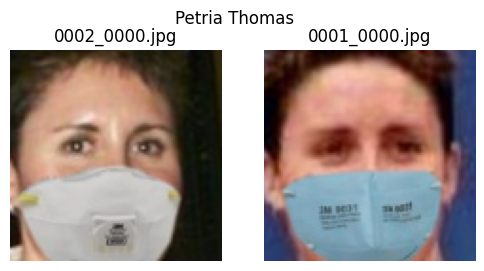

In [3]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random

# a pasta pai é convertida pra uma lista para ser passada como parametro do random.choice e ele retornar a pasta de uma celebridade aleatória
celebrity_path = random.choice(list(directory.iterdir()))

images = []
for i in celebrity_path.iterdir():
    img = np.asarray(Image.open(i))
    nome = i.name
    images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')

Se você rodar a célula acima mais de 1 vez, vai reparar um padrão. Analisando os nomes dos arquivos, não existe um padrão que indique se a imagem é com ou sem máscara eles apenas diferenciam variantes (os 4 primeiros números representam a identificação da imagem e os 4 últimos a variante da máscara). Por exemplo `Nome_0003_0000` e `Nome_0003_0001` mostram que é a mesma foto por conta dos 4 primeiros números *0003*, mas com uma variante de máscara  por conta dos 4 últimos números *0000* e *0001*. Agora a imagem `Nome_0001_000` é uma imagem diferente das outras, pois o os 4 primeiros números *0001* indicam isso

Vai também perceber que nem todas as celebridades possuem pelo menos uma foto de máscara e uma foto sem máscara. Isso seria um problema, pois para treinar Siamese Networks são necessários dois tipos de pares: pares positivos (duas imagens da mesma pessoa) e pares negativos (imagens de pessoas diferentes). O problema observado é que algumas celebridades podem não ter variedade suficiente de imagens (com e sem máscara) para formar pares positivos significativos para o problema proposto.

Outro problema seria a diferença de idades entre as imagens. Por exemplo, uma foto de máscara jovem e uma sem máscara mais velho, isso poderia impactar no treinamento do modelo, fazendo com que ele tratasse a mesma pessoa como pessoas diferentes pelo fator idade. Além disso, pode se deparar com o caso de imagens duplicadas, ou seja, a mesma imagem, mas com nome diferente.

De qualquer forma esses problemas serão mais analisados ao decorrer do notebook

# 2. Análise do dataset

## 2.1 Extensão e Imagens corrompidas

Primeiramente, irei verificar a extensão de cada imagem e se existe alguma imagem corrompida

In [4]:
from pathlib import Path
import pandas as pd

directory = Path('/kaggle/input/datasets/carlosvictor221/dataset-mascaras')

extensions = set()

for i in directory.rglob('*.*'):  
    extensions.add(i.suffix)

print(extensions)

{'.jpg'}


In [5]:
from PIL import Image

imagens_corrompidas = []

for i in directory.rglob('*.jpg'):
    try:
        with Image.open(i) as img:
            img.load()
    except:
        imagens_corrompidas.append(i) # adiciona imagens corrompidas na lista caso seja uma

print(imagens_corrompidas)

[]


Todas as imagens são .jpg e não existe nenhuma corrompida

## 2.2 Separação de pessoas válidas

Partiremos para a resolução do problema comentado na seção de apresentação do dataset. Como não temos um padrão no nomes das imagens indicando que é uma imagem da pessoa com ou sem máscara, optei por usar um modelo pré treinado do Hugging Face (Hemgg/Facemask-detection) que detecta se uma pessoa está de máscara ou não, para assim rotular as imagens de acordo. A ideia é assim que o modeo encontrar 1 imagem com máscara e 1 sem máscara para uma celebridade, ele para de processar aquela pasta e passa para a próxima. No pior caso, ele percorre todas as imagens e no melhor caso ele vai parar em 2.

In [6]:
!pip install transformers

In [7]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Usar a GPU

processor = AutoImageProcessor.from_pretrained("Hemgg/Facemask-detection")
model = AutoModelForImageClassification.from_pretrained("Hemgg/Facemask-detection")
model.to(device)

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [8]:
model.config

ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "dtype": "float32",
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "WithMask",
    "1": "WithoutMask"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "WithMask": "0",
    "WithoutMask": "1"
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "problem_type": "single_label_classification",
  "qkv_bias": true,
  "transformers_version": "5.0.0"
}

In [9]:
print(processor)

ViTImageProcessorFast {
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



O modelo foi carregado e setado para usar a GPU do Kaggle para classificar as imagens mais rapidamente. Usando o model.config para verificar como o modelo classifica vemos a chave "id2label": {"0": "WithMask","1": "WithoutMask"}, então precisamos comparar as imagens de acordo com essa label. 

### 2.2.1 Análise de canais de cor das imagens

Outro ponto é que o modelo só aceita imagens com 3 canais (RGB) sendo possível obsersevar através da chave "num_channels": 3 e o processor não faz essa conversão automaticamente. Rodando a célula que mostra as imagens na seção de apresentação do dataset enventualmente você pode achar uma imagem em preto e branco na escala de cinza. Então antes de passar as imagens para o modelo é preciso verificar se as imagens que estão em preto e branco realmente usam apenas 1 canal

In [10]:
from PIL import Image

gray_imgs = []

for i in directory.rglob('*.jpg'):
    with Image.open(i) as img:
        if img.mode == 'L': # faz a verificaçao se a imgagem tem apenas 1 canal
            gray_imgs.append(i)

len(gray_imgs)

0

Como o total de imagens com apenas 1 escala resultou em zero, siginifica que todas as imagens foram salvas como RGB

Abaixo, o codigo percorre cada pasta e depois cada imagem dentro da pasta. As flags `has_no_mask` e `has_mask` são setadas como False para usarmos de condição de parada. Dentro do loop percorremos por cada imagem e passamos ela de entrada para o modelo, o modelo então devolve a label e fazemos a verificação se é uma imagem de uma pessoa de máscara ou sem máscara (0 ou 1). Como a ideia é verificar se temos pares válidos, ou seja, pelo menos 1 imagem sem máscara e 1 imagem de máscara, então setamos as flags para True quando a condição é satisfeita. Quando as duas flags são marcadas como True, então aquela pessoa é válida e podemos parar de percorrer as imagens dela. No final adicionamos o caminho da pasta em uma lista para usarmos futuramente.

In [11]:
valid_persons = []

for paths in directory.iterdir(): # loop para cada pasta
    has_no_mask = False
    has_mask = False
    
    for image in paths.rglob('*.jpg'): # loop para cada imagem dentro da pasta
        with Image.open(image) as img:
            inputs = processor(img, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()} # pra rodar com a GPU
            outputs = model(**inputs)
            label = outputs.logits.argmax().item() # retorna nossa label 0 ou 1, 0 = Máscara, 1 = Sem Máscara
            if label == 0:
                has_mask = True
            else:
                has_no_mask = True
        
        if has_mask and has_no_mask: # Condição de parada do loop das imagens, significa que encontrou o par válido
            break

    if has_mask and has_no_mask:
        valid_persons.append(paths)

len(valid_persons)

1894

In [12]:
import pickle, os

with open('valid_persons.pkl', 'wb') as f:
    pickle.dump(valid_persons, f)

In [2]:
import pickle, os

with open('/kaggle/working/valid_persons.pkl', 'rb') as f:
    valid_persons = pickle.load(f)

Após a classificação feita com a ajuda do modelo, o dataset caiu de 2996 pessoas para 1894. Abaixo é feita novamente a plotagem das imagens, mas dessa vez usando o dataset reduzido com as pessoas válidas.

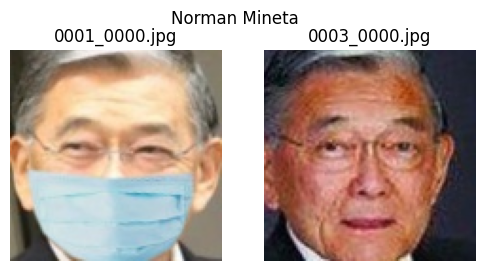

In [14]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity_path = random.choice(valid_persons)

images = []
for i in celebrity_path.iterdir():
    img = np.asarray(Image.open(i))
    nome = i.name
    images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')

## 2.3 Resolvendo duplicatas

Apesar de parecer resolvido, ainda existem dados a serem tratados. Se você rodou a célula de código acima mais de 1 vez, pode ter se deparado com casos em que existem duplicatas nas imagens, problema que ainda não foi tratado. Isso seria um problema, pois se o modelo forma um par com essas imagens iguais irá resultar em uma distância nula e com isso ele pode aprender que esse é o correto.

In [15]:
total = sum(1 for path in valid_persons for img in path.rglob('*.jpg'))
total

8870

O total de de todas as imagens do nosso dataset é de 8870, iremos tratar as duplicatas e removelas, então esse valor deve decair um pouco

In [16]:
import hashlib
from PIL import Image

duplicates = set()
seen_hashes = {}

for paths in valid_persons: # loop pra percorrer o dataset de pessoas validas
    for image in paths.rglob('*'): # loop pra percorrer as imagens dentro das pastas
        hash_images = hashlib.sha256() # cria um container hash
        
        with Image.open(image) as img:
            img_bytes = img.tobytes() # converte a imagem para bytes
            hash_images.update(img_bytes) # salva no container os bytes da imagem
            hash_img_str = hash_images.hexdigest() # recupera como string
            
            if hash_img_str in seen_hashes: # verifica se a imagem já nao está no dicionário de hashes
                duplicates.add((hash_img_str, image)) # caso estiver, adiciona no set de imagens duplicadas
            else:
                seen_hashes[hash_img_str] = image # se nao estiver, salva no dicionario o hash como chave e o caminho dela como valor

len(list(duplicates))

500

Foi possível verificar um total de 500 imagens duplicadas, utilizando a estratégia de transformar a imagem em hash e comparar os hashses entre si. A lógica é que se um hash for igual ao outro significa que é uma duplicata, então salvamos ela num set de duplicatas junto com seu caminho, se não for igual salvamos em um dicionarios de hashes vistos com o hashs da imagem sendo sua chave e o caminho da imagem seu valor. Essa estratégia foi adotata para poder plotar as imagens duplicadas e a original

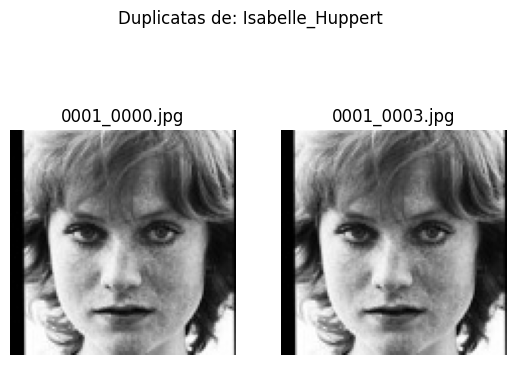

In [17]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity = random.choice(list(duplicates))

duplicate_img = np.asarray(Image.open(celebrity[1])) # caminho da imagem duplicada 
original_img = np.asarray(Image.open(seen_hashes[celebrity[0]])) # caminho da imagem original usando o hash da tupla de duplicates

fig, axs = plt.subplots(1, 2)
fig.suptitle(f'Duplicatas de: ' + celebrity[1].parent.name)
titulo_original = seen_hashes[celebrity[0]].name.split('_')[-2:]
titulo_duplicata = celebrity[1].name.split('_')[-2:]

axs[0].imshow(original_img)
axs[1].imshow(duplicate_img)
axs[0].set_title('_'.join(titulo_original).replace(' ', '_'))
axs[1].set_title('_'.join(titulo_duplicata).replace(' ', '_'))
axs[0].axis('off')
axs[1].axis('off')
plt.show()

Rodando a célula acima várias vezes é possível notar que a estratégia de usar o hash das imagens conseguiu capturar as imagens duplicadas. Iremos então fazer a remoção delas.

In [18]:
valid_images = []

duplicate_paths = {dup[1] for dup in duplicates}

for paths in valid_persons:
    for imgs in paths.rglob('*'):
        if imgs not in duplicate_paths:
            valid_images.append(imgs)

len(valid_images)

8370

In [19]:
import os

with open('valid_images.pkl', 'wb') as f:
    pickle.dump(valid_images, f)

In [3]:
import os

with open('/kaggle/working/valid_images.pkl', 'rb') as f:
    valid_images = pickle.load(f)

Com a remoção das duplicatas, o número de imagens caiu de 8870 para 8370

Abaixo é mostrado alguns exemplos de como o dataset ficou removendo as duplicatas do conjunto de pessoas válidas

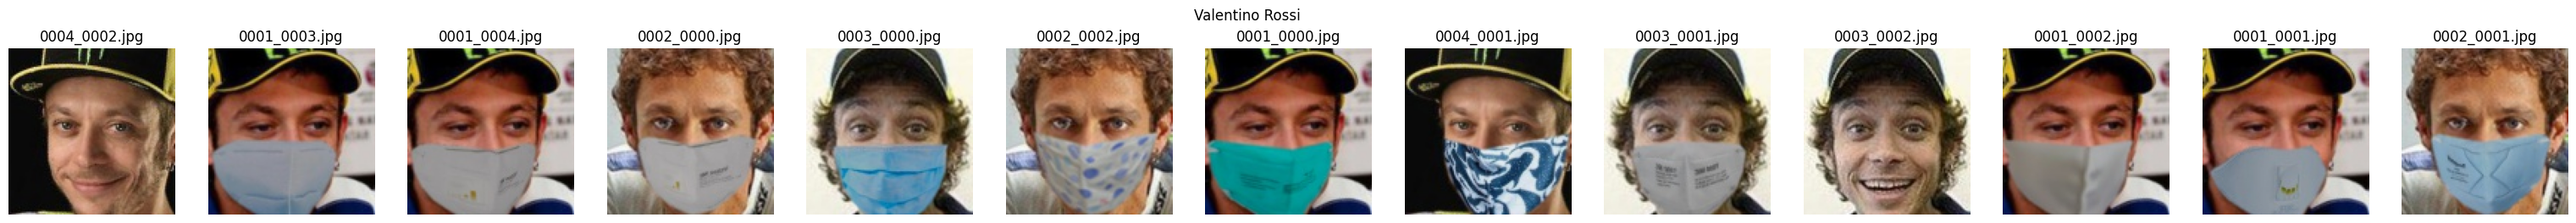

In [21]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity_img = random.choice(valid_images)
celebrity_path = celebrity_img.parent
valid_images_set = set(valid_images)

images = []
for i in celebrity_path.iterdir():
    if i in valid_images_set:
        img = np.asarray(Image.open(i))
        nome = i.name
        images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')


## 2.4 Verificando medidas das imagens

Antes de colocar as imagens em um modelo, é necesário verificar a largura e altura de todas as imagens, pois normalmente o modelo espera um tamanho fixo. No código abaixo, percorrermos as imagens válidas e salvamos as altura e largura de cada uma em listas para plotar em um scatter plot.

In [22]:
from PIL import Image

heights = []
widths = []

for images in valid_images:
    with Image.open(images) as img:
        width, height = img.size
        widths.append(width)
        heights.append(height)

print(len(heights))
print(len(widths))

8370
8370


A ideia de usar um scatter plot é mostrar visualmente a relação de altura e largura das imagens, onde cada ponto no gráfico representaria uma imagem, ou seja, se existirem muitos pontos dispersos, então o dataset tem imagens com tamanho diferente.

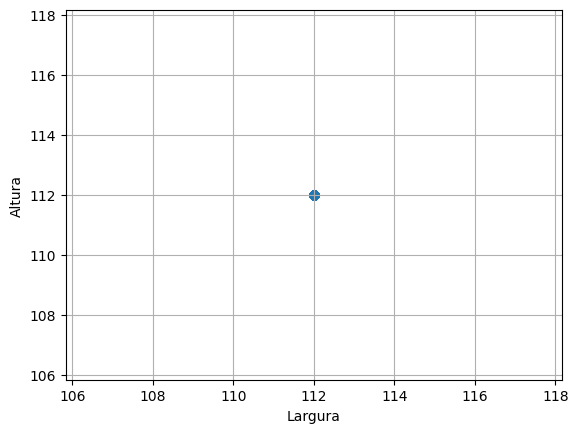

In [23]:
import matplotlib.pyplot as plt

plt.scatter(widths, heights)
plt.grid(True)
plt.xlabel('Largura')
plt.ylabel('Altura')
plt.show()

O gráfico mostra apenas um ponto em (112, 112) nos dizendo que todas as imagens do dataset possuem exatamente o mesmo tamanho. Isso simplifica o treinamento, pois não será preciso fazer um redimensionamento das imagens

## 2.5 Tratando desbalaceamento

Separamos o total de imagens por pessoa em um dicionário, para assim saber transformar em um dataframe e então plotar e visualizar essa distribuição

In [24]:
count_images = {}
valid_images_set = set(valid_images)

for paths in valid_persons:
    for imgs in paths.rglob('*'):
        if imgs in valid_images_set:
            if imgs.parent.name not in count_images:
                count_images[imgs.parent.name] = 1
            else:
                count_images[imgs.parent.name] +=1

dict(list(count_images.items())[:5]) 

{'Tyler_Hamilton': 2,
 'Blythe_Danner': 2,
 'Gene_Robinson': 6,
 'Coco_dEste': 2,
 'Ralph_Sampson': 2}

In [25]:
import pandas as pd

df = pd.DataFrame(count_images.items(), columns=['pessoa', 'total_imagens']) # transforma o dicionário em um dataframe
df.head()

,pessoa,total_imagens
0,Tyler_Hamilton,2
1,Blythe_Danner,2
2,Gene_Robinson,6
3,Coco_dEste,2
4,Ralph_Sampson,2


In [26]:
df.describe()

,total_imagens
count,1894.000000
mean,4.419219
std,3.087485
min,2.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,26.000000


Veremos essas métricas acimas de uma maneira visual com o gráfico abaixo

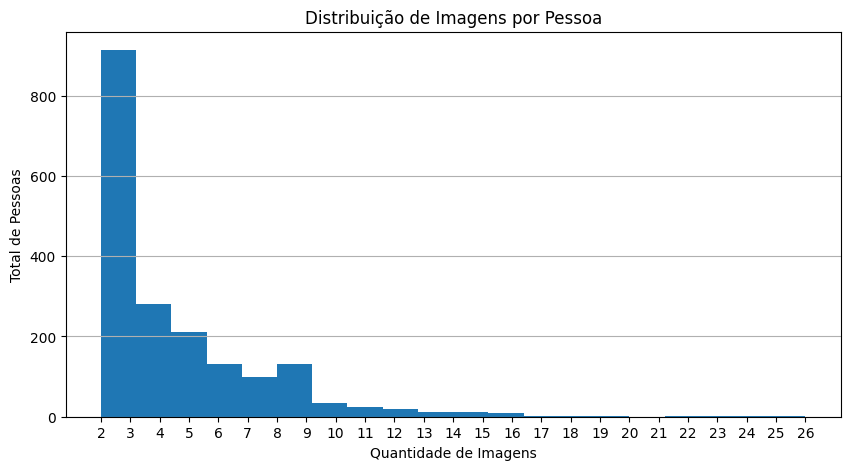

In [27]:
plt.figure(figsize=(10,5))
plt.hist(df['total_imagens'], bins=20)
plt.xticks(range(min(df['total_imagens']), max(df['total_imagens'])+1, 1)) 
plt.grid(axis='y')
plt.xlabel('Quantidade de Imagens')
plt.ylabel('Total de Pessoas')
plt.title('Distribuição de Imagens por Pessoa')
plt.show()

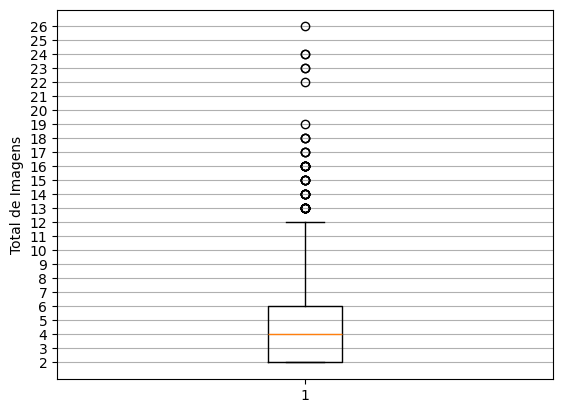

In [28]:
plt.boxplot(df['total_imagens'])
plt.ylabel('Total de Imagens')
plt.yticks(range(2, 27, 1))
plt.grid(axis='y')
plt.show()

In [29]:
filtro = df['total_imagens'] == 2
print(df[filtro].count())

print(df[df['total_imagens'] ==  3].count())

pessoa           741
total_imagens    741
dtype: int64
pessoa           173
total_imagens    173
dtype: int64


Observando aa distribuição, é possível notar um claro desbalanceamento. A maioria das pessoas tem entre 2-3 imagens, mais especificamente 741 pessoas possuem 2 imagens e 173 possuem 3 imagens, totalizando 914 pessoas. Como fizemos a rotulação com o modelo sabemos que ela tem ao menos 1 foto de máscara e 1 foto sem máscara. Olhando o boxplot é possível reparar que o limite inferior e o Q1 correspondem a 2 imagens também, a mediana em 4 imagens e o Q3 em 6 imagens.

Para balancear o dataset, a estratégia adotada será exigir um mínimo de 3 imagens por pessoa, excluindo as 741 pessoas que possuem apenas 2 imagens. Dessa forma, todas as pessoas restantes contribuem igualmente com 3 pares positivos cada, totalizando 1153 pessoas × 3 pares = 3459 pares positivos. Essa uniformidade é importante para evitar que o modelo seja enviesado para pessoas com mais amostras. Usar um mínimo de 2 geraria apenas 1 par por pessoa (1894 pares no total), insuficiente para um bom aprendizado, enquanto um mínimo maior que 3 reduziria demais o número de identidades no dataset. Faremos isso na seção de treinamento do modelo, quando formos separar os pares

Em seguida rodarei novamente o modelo pré treinado de detecção de máscara, mas dessa vez com o objetivo de rotular as imagens da lista de imagens válidas. A ideia de fazer isso é para quando for limitar o modelo para pessoas com pelo menos 3 imagens, garantir de forma mais fácil 1 imagem com máscara e 1 sem máscara. Como abordado antes, os nomes das imagens não indicam se a pessoa está com ou sem máscara. Sem essa rotulação prévia, ao limitar para 3 imagens por pessoa, a seleção seria aleatória e poderia resultar em 3 imagens sem nenhum exemplo com máscara.

In [30]:
from PIL import Image

valid_dataset = []

for images in valid_images:
    with Image.open(images) as img:
        inputs = processor(img, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        label = outputs.logits.argmax().item()
        if label == 0:
            valid_dataset.append({'pessoa':images.parent.name, 'caminho': images, 'label': 0})
        else:
            valid_dataset.append({'pessoa':images.parent.name, 'caminho': images, 'label': 1})

Transformando o dicionário feito acima para um dataframe para ficar mais fácil de trabalhar futuramente

In [31]:
with open('valid_dataset.pkl', 'wb') as f:
    pickle.dump(valid_dataset, f)

In [4]:
import pickle, os

with open('/kaggle/working/valid_dataset.pkl', 'rb') as f:
    valid_dataset = pickle.load(f)

In [5]:
import pandas as pd

df_valid_dataset = pd.DataFrame(valid_dataset)
df_valid_dataset.head()

,pessoa,caminho,label
0,Tyler_Hamilton,/kaggle/input/datasets/carlosvictor221/dataset...,0
1,Tyler_Hamilton,/kaggle/input/datasets/carlosvictor221/dataset...,1
2,Blythe_Danner,/kaggle/input/datasets/carlosvictor221/dataset...,0
3,Blythe_Danner,/kaggle/input/datasets/carlosvictor221/dataset...,1
4,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0


# 3. Treinamento do Modelo

O modelo recebe pares de imagens, onde eles são classificados como pares positivos e pares negativos. Os pares positivos seriam um par de imagens da mesma pessoa e os negativos um par formando por imagens de pessoas diferentes. Através da distância das features extraidas do rosto, se for um par positvo ele conseguirá determinar que é a mesma pessoa, pois terão distâncias curtas, agora se for um par negativo ele irá identificar que são pessoas diferentes por terem a distância muito maior.

## 3.1 Tomada de Decisão: abordagem inicial incorreta

Essa parte do notebook é apenas pra evidenciar uma abordagem que tomei que notei que estava errada. Separei o dataset em conjuntos de teste, treino e validação e percebi que o dataset está desbalanceado no sentido de que existem pessoas que tem mais imagens do que outras. Isso seriam ruim, pois dessa forma o modelo não iria aprender a generalizar, apenas a memorizar.

In [34]:
from sklearn.model_selection import train_test_split


names = [img.parent.name for img in valid_images]

train_images, temp_images, train_identities, temp_identities = train_test_split(valid_images, names, test_size=0.3, random_state=42)

val_images, test_images, val_identities, test_identities = train_test_split(temp_images, temp_identities, test_size=0.5, random_state=42)

print(f'Imagens de treino: {len(train_images)}')
print(f'Identidades de treino: {len(train_identities)}')
print(f'Imagens de validação: {len(val_images)}')
print(f'Identidades de validação: {len(val_identities)}')
print(f'Imagens de teste: {len(test_images)}')
print(f'Identidades de teste: {len(test_identities)}')

Imagens de treino: 5859
Identidades de treino: 5859
Imagens de validação: 1255
Identidades de validação: 1255
Imagens de teste: 1256
Identidades de teste: 1256


In [35]:
persons = {}

for index, identity in enumerate(train_identities):
    if identity not in persons:
        persons[identity] = []
    persons[identity].append(index)

dict(list(persons.items())[:5]) 

{'Arianna_Huffington': [0,
  144,
  513,
  1852,
  3079,
  3567,
  3686,
  3748,
  3906,
  4072,
  4232,
  4284,
  4665,
  4824,
  4967,
  5508,
  5627,
  5637,
  5788,
  5835],
 'George_Allen': [1, 2830],
 'Michael_Goldrich': [2, 572, 2355],
 'Faisal_Saleh_Hayat': [3, 1955],
 'Ray_Liotta': [4, 1616]}

A ideia do código acima seria de montar um dicionário, onde a chave seria a pessoa e os valores uma lista dos índices das imagens dela. Dessa forma fica muito mais fácil achar as imagens. Por exemplo para formar um par positivo bastaria percorrer o dicionario com o nome da pessoa na forma `persons['Arianna_Huffington']` e pegar dois índices diferentes, para um par negativo pegaria dois indices de pessoas diferentes. Como o indice aponta para a posição da imagem, então percorriamos a lista das imagens de treinos com `train_images[indice]` e assim conseguiriamos achar a imagem.

Ao fazer isso e listar o dicionário, percebi que algumas pessoas possuem muito mais imagens do que outras mostrando um desbalanceamento claro, então voltarei para o tópico da análise do dateset para tentar achar um balanceamento melhor.

## 3.2 Cap das imagens

Primeiramente é feito um novo dataframe para podermos contar o total de imagens por pessoa, semelhante ao que fizemos mais acima para plotar o gráfico de distribuição. Porém o objetivo dessa vez vai ser filtrar quem tem mais de 2 imagens no total.

In [6]:
df_person_per_img = df_valid_dataset.groupby(by=['pessoa'], as_index=False).agg(
    total=('caminho','count')
)

df_person_per_img

,pessoa,total
0,Aaron_Eckhart,6
1,Aaron_Peirsol,12
2,Aaron_Tippin,2
3,Abdel_Aziz_Al-Hakim,2
4,Abdel_Nasser_Assidi,2
...,...,...
1889,Zhu_Rongji,2
1890,Zico,7
1891,Zinedine_Zidane,3
1892,Zoe_Ball,2


Filtramos então as pessoas que possuem mais de 2 fotos e transformamos em uma lista, em seguida essa lista de nomes é passada para nossa função `isin()` que retorna uma série de booleanos. Nessa série, os valores *True* indicam as pessoas que tem mais de 2 fotos e consequentemente os valores *False* indicam que tem exatamente 2 imagens. Por fim passamos a serie booleana como filtro final do nosso dataframe para assim excluir as pessoas com 2 imagens.

In [7]:
list_names = df_person_per_img[df_person_per_img['total'] > 2]['pessoa'].tolist()
person_serie = df_valid_dataset['pessoa'].isin(list_names)

In [38]:
len(list_names)

1153

In [39]:
person_serie

0       False
1       False
2       False
3       False
4        True
        ...  
8365     True
8366     True
8367     True
8368     True
8369     True
Name: pessoa, Length: 8370, dtype: bool

In [40]:
df_valid_dataset = df_valid_dataset[person_serie]
df_valid_dataset

,pessoa,caminho,label
4,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
5,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
6,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
7,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
8,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
8365,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8366,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8367,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8368,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0


Feita a filtragem, partimos para uma separação de imagens com a label 0 e a label 1. A ideia dessa separação é fazer mais a frente outra separação, mas dessa vez seguindo o padrão de pegar uma foto de máscara, uma foto sem máscara e outra foto aleatória. Isso porque precisamos limitar as pessoas que possuem mais de 3 imagens, garantindo que todas as pessoas do nosso dataset tenha 3 imagens, ou seja, as pessoas que tem exatamente 3 imagens vão continuar com as 3 e as pessoas que possuem mais de 3 imagens, vão passar a ter somente 3 no total.

In [41]:
masked = df_valid_dataset[df_valid_dataset['label'] == 0]
unmasked = df_valid_dataset[df_valid_dataset['label'] == 1]

In [42]:
masked

,pessoa,caminho,label
4,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
5,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
6,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
7,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0
16,Colin_Powell,/kaggle/input/datasets/carlosvictor221/dataset...,0
...,...,...,...
8365,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8366,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8367,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0
8368,Barry_Collier,/kaggle/input/datasets/carlosvictor221/dataset...,0


In [43]:
unmasked

,pessoa,caminho,label
8,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,1
9,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,1
14,Colin_Powell,/kaggle/input/datasets/carlosvictor221/dataset...,1
15,Colin_Powell,/kaggle/input/datasets/carlosvictor221/dataset...,1
24,Luke_Walton,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
8347,Michael_Bloomberg,/kaggle/input/datasets/carlosvictor221/dataset...,1
8353,Michael_Bloomberg,/kaggle/input/datasets/carlosvictor221/dataset...,1
8357,Valerie_Harper,/kaggle/input/datasets/carlosvictor221/dataset...,1
8361,Valerie_Harper,/kaggle/input/datasets/carlosvictor221/dataset...,1


Pegamos então um nome da lista de nomes que criamos mais acima e tiramos uma linha aleatória de cada dataframe (masked e unmasked), então a terceira imagem precisa ser uma diferente dessas aleatórias escolhidas. Para isso fazemos um filtro, onde excluiremos essas imagens já escolhidas e pegaremos uma aleatória dentre as que sobraram, dessa forma garantimos que a terceira será diferente das que já foram escolhidas. A ideia de fazer a terceira ser aleatória é para adicionar variação, com ela podendo ser com ou sem máscara, enriquece o aprendizado do modelo.

In [44]:
import pandas as pd

temp_list = []

for name in list_names:
    masked_img = masked[masked['pessoa'] == name].sample()
    unmasked_img = unmasked[unmasked['pessoa'] == name].sample()
    third_img = df_valid_dataset[(df_valid_dataset['pessoa'] == name) & (~df_valid_dataset.index.isin([masked_img.index, unmasked_img.index]))].sample()
    temp_list.append(pd.concat([masked_img, unmasked_img, third_img]))


df_final_dataset = pd.concat(temp_list).reset_index(drop=True)
df_final_dataset

,pessoa,caminho,label
0,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,0
1,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,1
2,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,0
3,Aaron_Peirsol,/kaggle/input/datasets/carlosvictor221/dataset...,0
4,Aaron_Peirsol,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
3454,Zinedine_Zidane,/kaggle/input/datasets/carlosvictor221/dataset...,1
3455,Zinedine_Zidane,/kaggle/input/datasets/carlosvictor221/dataset...,0
3456,Zoran_Djindjic,/kaggle/input/datasets/carlosvictor221/dataset...,0
3457,Zoran_Djindjic,/kaggle/input/datasets/carlosvictor221/dataset...,1


In [45]:
with open('df_final_dataset.pkl', 'wb') as f:
    pickle.dump(df_final_dataset, f)

In [8]:
import pickle, os

with open('/kaggle/working/df_final_dataset.pkl', 'rb') as f:
    df_final_dataset = pickle.load(f)

## 3.3 Separação dos conjuntos

A separação precisa ser por pessoa (não por imagem) para evitar data leakage, ou seja, a mesma pessoa não pode aparecer no treino e no teste. Se isso acontecesse o modelo não iria apenas decorar a pessoa e não de fato aprender a identificar ela.

Inicialmente, achei que passando o caminho das imagens a separação já seria feita. Porém eles têm tamanhos diferentes, o df_final_dataset tem 3 linhas por pessoa (3459 linhas) e list_names tem 1153 nomes. Temos então que separar a lista de nomes em treino/validação/teste e depois filtrar o df_final_dataset por esses nomes.

In [9]:
from sklearn.model_selection import train_test_split

train_names, temp_names = train_test_split(list_names, test_size=0.3, random_state=42)
val_names, test_names = train_test_split(temp_names, test_size=0.5, random_state=42)

print(f'Pessoas de treino: {len(train_names)}')
print(f'Pessoas de validação: {len(val_names)}')
print(f'Pessoas de teste: {len(test_names)}')

Pessoas de treino: 807
Pessoas de validação: 173
Pessoas de teste: 173


Seguindo um padrão de 75% de treino, 15% de teste de 15% de validação o conjunto de treino ficou com 807 pessoas com 2421 imagens e os dois outros com 173 pessoas e 519 imagens cada

In [10]:
df_train = df_final_dataset[df_final_dataset['pessoa'].isin(train_names)]
df_val = df_final_dataset[df_final_dataset['pessoa'].isin(val_names)]
df_test = df_final_dataset[df_final_dataset['pessoa'].isin(test_names)]

In [49]:
df_train

,pessoa,caminho,label
0,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,0
1,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,1
2,Aaron_Eckhart,/kaggle/input/datasets/carlosvictor221/dataset...,0
3,Aaron_Peirsol,/kaggle/input/datasets/carlosvictor221/dataset...,0
4,Aaron_Peirsol,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
3451,Zico,/kaggle/input/datasets/carlosvictor221/dataset...,1
3452,Zico,/kaggle/input/datasets/carlosvictor221/dataset...,1
3456,Zoran_Djindjic,/kaggle/input/datasets/carlosvictor221/dataset...,0
3457,Zoran_Djindjic,/kaggle/input/datasets/carlosvictor221/dataset...,1


In [50]:
df_val

,pessoa,caminho,label
6,Abdoulaye_Wade,/kaggle/input/datasets/carlosvictor221/dataset...,0
7,Abdoulaye_Wade,/kaggle/input/datasets/carlosvictor221/dataset...,1
8,Abdoulaye_Wade,/kaggle/input/datasets/carlosvictor221/dataset...,0
9,Abdullah_Gul,/kaggle/input/datasets/carlosvictor221/dataset...,0
10,Abdullah_Gul,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
3418,Xanana_Gusmao,/kaggle/input/datasets/carlosvictor221/dataset...,1
3419,Xanana_Gusmao,/kaggle/input/datasets/carlosvictor221/dataset...,0
3444,Zeljko_Rebraca,/kaggle/input/datasets/carlosvictor221/dataset...,0
3445,Zeljko_Rebraca,/kaggle/input/datasets/carlosvictor221/dataset...,1


In [51]:
df_test

,pessoa,caminho,label
18,Adam_Ant,/kaggle/input/datasets/carlosvictor221/dataset...,0
19,Adam_Ant,/kaggle/input/datasets/carlosvictor221/dataset...,1
20,Adam_Ant,/kaggle/input/datasets/carlosvictor221/dataset...,0
30,Adrian_Annus,/kaggle/input/datasets/carlosvictor221/dataset...,0
31,Adrian_Annus,/kaggle/input/datasets/carlosvictor221/dataset...,1
...,...,...,...
3439,Yukiko_Okudo,/kaggle/input/datasets/carlosvictor221/dataset...,1
3440,Yukiko_Okudo,/kaggle/input/datasets/carlosvictor221/dataset...,1
3453,Zinedine_Zidane,/kaggle/input/datasets/carlosvictor221/dataset...,0
3454,Zinedine_Zidane,/kaggle/input/datasets/carlosvictor221/dataset...,1


In [11]:
train_images = df_train['caminho']
train_identities = df_train['pessoa']

val_images = df_val['caminho']
val_identities = df_val['pessoa']

test_images = df_test['caminho']
test_identities = df_test['pessoa']

## 3.4 Treinamento do modelo

### 3.4.1 CustomImageDataset

Primeiro é criado um CustomImageDataset para podermos preparar as imagens do modelo. A ideia é simples, receber os caminhos das imagens e a quem essa imagem corresponde, então a classe vai abrir a imagem, converter ela em tensor e retornar a imagem como tensor e a pessoa da respectiva imagem. A conversão em tensor é feita, pois o PyTorch trabalha apenas com tensores e não com imagens PIL

In [53]:
import torch 
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, train_images, train_identities): # recebe os dfs dos caminhos das imagens e o nome da pessoa
        self.train_images = train_images
        self.train_identities = train_identities

    def __len__(self):
        return len(self.train_images)

    def __getitem__(self, idx):
        with Image.open(self.train_images.iloc[idx]) as img: # abrir a imagem
            image = transforms.ToTensor()(img) # transforma em tensor
            
        return image, self.train_identities.iloc[idx] # retorna o tensor da imagem e a pessoa a quem ela corresnponde

In [54]:
train_dataset = CustomImageDataset(train_images, train_identities)
test_dataset = CustomImageDataset(test_images, test_identities)
val_dataset = CustomImageDataset(val_images, val_identities)

Passamos então cada dataframe para podermos criar os datasets separados

### 3.4.2 CustomSampler

In [55]:
from torch.utils.data import Sampler
import random

class CustomSampler(Sampler):
    def __init__(self, dataset, person_per_batch, img_per_person=3):
        self.dataset = dataset
        self.person_per_batch = person_per_batch # recebe o numero de pessoa por batch
        self.img_per_person = img_per_person # recebe o numero de imagens por pessoa
        self.idx_imgs = {} # dicionario para salvar os indices das imagens dessa pessoa
        for idx in range(len(dataset)): # percorre os indices do dataset
            if dataset.train_identities.iloc[idx] not in self.idx_imgs: # se a pessoa nao esta no dataset
                self.idx_imgs[dataset.train_identities.iloc[idx]] =  [] # cria uma lista de indices
            self.idx_imgs[dataset.train_identities.iloc[idx]].append(idx) # adiciona os indices das imagens dessa pessoa

    def __len__(self):
        return len(self.dataset)

    def __iter__(self):
        persons = random.sample(list(self.idx_imgs.keys()), self.person_per_batch) # sorteia pessoas aleatorias do dicionario
        self.lista = []
        for person in persons:
            idxs_list = self.idx_imgs[person] # lista dos indices da pessoa
            idxs = random.sample(idxs_list, self.img_per_person)
            self.lista.extend(idxs)
        return iter(self.lista)

A ideia de criar um CustomSampler surgiu após um erro na parte de treinamento do modelo. Ele retornou um erro onde não conseguia continuar, pois a lista de triplets estava vazia, o batch não tinha nenhuma pessoa com um par positivo válido, isso pelo fato de termos poucas pessoas no dataset e usando um DataLoader aletório, num batch de 32 imagens poderia aparecer 32 pessoas diferentes, isto é, uma imagem de cada então quando buscava um par positivo não encontrava ninguém. O CustomSampler então garante que em cada batch tenha N pessoas com X imagens. No caso setei 32 pessoas × 3 imagens = 96 imagens por batch, assegurando que sempre haverá pares positivos disponíveis para formar os triplets.

In [15]:
# setando as seeds
import random
import torch
import numpy as np

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [57]:
from torch.utils.data import DataLoader

person_per_batch = 32
img_per_person = 3
batch_size = person_per_batch*img_per_person

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=CustomSampler(train_dataset, person_per_batch))
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, sampler=CustomSampler(test_dataset, person_per_batch))
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, sampler=CustomSampler(val_dataset, person_per_batch))

### 3.4.3 Backbone

Seguimos então carregando modelo pré-treinado para ser nosso backbone, isso é, aquele modelo que vai extrair as features do rosto da pessoa gerando o embedding. Como o modelo pré-treinado já aprendeu features visuais genéricas (bordas, texturas, formas) no ImageNet a ideia então é aproveitar esse conhecimento apenas ajustando para o problema de faces com máscaras.

In [58]:
import torch
from torchvision.models import resnet18

backbone = resnet18(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


In [59]:
backbone.fc

Linear(in_features=512, out_features=1000, bias=True)

In [60]:
import torch.nn as nn

backbone.fc = nn.Linear(512, 128)
backbone.fc

Linear(in_features=512, out_features=128, bias=True)

O modelo orignal gera embeddings com 1000 dimensões, então setei para gera com 128. Isso porque 1000 dimensões, poderia gerar muito ruído e dificultaria o aprendizado, além disso 128 é o padrão usado no FaceNet.

FaceNet é o modelo do Google (2015) que popularizou o uso de Triplet Loss para reconhecimento facial e introduziu o embedding de 128 dimensões como padrão da área.

In [61]:
import torch.nn.functional as F

class Normalize(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, img):
        result = self.backbone(img)
        return F.normalize(result)

In [62]:
model = Normalize(backbone)

O FaceNet usa L2 normalization nos embeddings antes de calcular a distância euclidiana. Basicamente essa normalização pega cada embedding e divide ele pelo seu comprimento, fazendo com que todos fiquem com magnitude 1 e então assim calcula a distância entre eles usando a distância euclidiana.

Isso é feito pois, a distância euclidiana é uma subtração e uma raiz quadrada. A distância do cosseno exige calcular a norma de cada vetor antes da divisão, isso exige mais processamento. Com L2 normalization feita uma vez só na saída do modelo, esse custo extra é eliminado na hora de comparar os embeddings.

Dessa forma om os vetores normalizados com a L2 normalization, a distância euclidiana e distância do cosseno são matematicamente equivalentes, então o mesmo resultado do cosseno é obtido com um cálculo mais simples.

In [63]:
triplet_loss = nn.TripletMarginLoss(margin=1.0, p=2)

A função de perda escolhida foi a Triplet Loss, ela vai calcular o quanto nosso modelo evolui através dela. A ideia é que quanto menor ela for melhor o modelo desempenha. A Triplet Loss calcula a distância entre os embeddings usando 3 entradas, que vão ser o anchor a foto de base, o positive que é outra foto da mesma pessoa e o negative que é a foto de outra pessoa. Dessa forma formamos os pares positivos e negativos que a Siamese Netwrok precisa. Ela tenta garantir que a distância entre anchor e positive seja menor que a distância entre anchor e negative por uma margem. O modelo aprende a aproximar embeddings da mesma pessoa e afastar embeddings de pessoas diferentes.

A margem vai definir uma "folga" mínima entre as distâncias. Por exemplo, com margem 1, não basta o anchor estar mais perto do positive que do negative ele precisa estar pelo menos 1 mais perto. Isso evita que o modelo encontre soluções triviais onde as distâncias são quase iguais.

In [64]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

O optimizer vai receber os gradientes calculados e usar eles para atualizar os pesos do modelo. O Adam é o optimizer mais usado por padrão porque ele adapta a taxa de aprendizado para cada peso individualmente, ou seja, pesos que mudam muito recebem atualizações menores, pesos que mudam pouco recebem atualizações maiores.

Carregamos o modelo então para a GPU

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Normalize(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

O ResNet18 então é o backbone da Siamese Network, ele extrai o embedding de cada imagem. Como os pesos são compartilhados, ou seja, é o mesmo modelo para todas as imagens, isso já caracteriza uma Siamese Network. A Triplet Loss então compara os embeddings gerados e ensina o modelo a organizar o espaço de embeddings corretamente

### 3.4.4 Loop de Treinamento e Validação

In [66]:
import numpy as np
import random

list_loss_train = []
list_loss_val = []

best_val_loss = float('inf')
patience_counter = 0 
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_val_loss = 0
    for batch in train_dataloader: # loop sobre os batchs de treino
        images, identities = batch  # extrai os tensores em imagens e identidades
        images = images.to(device) # manda a imagem para o GPU
        embedding = model(images) # extrai as features do rosto de cada imagem do batch com 128 dimensoes cada
        ids = np.array(identities) # transforma os nomes das pessoas em um array
        mask = torch.tensor(ids[:, None] == ids[None, :]) # faz uma matriz de máscaras, onde True indica que é a mesma pessoa e False pessoa diferente
        triplets = [] # lista para armazenar os triplets anchor, positive e negative
        for i in range(len(embedding)): # percorre os index dos embeddings
            positives_idxs = torch.where(mask[i]) # separa os indexs positivos da máscara
            negatives_idxs = torch.where(~mask[i]) # separa os index negativos
            valid_positive = positives_idxs[0][positives_idxs[0] != i].tolist() # converte para uma lista com o filtro diferente do indice
            valid_negative = negatives_idxs[0].tolist()
            if len(valid_positive) == 0 or len(valid_negative) == 0:
                continue      
            positive = random.choice(valid_positive) # escolhe 1 linha postive excluindo o proprio i que será o anchor
            negative = random.choice(valid_negative) # escolhe 1 linha negative
            triplets.append((embedding[i], embedding[positive], embedding[negative])) # salva na lista 
        
        anchors = torch.stack([t[0] for t in triplets]) # desempacota os anchors
        positives = torch.stack([t[1] for t in triplets]) # desempacota os positives
        negatives = torch.stack([t[2] for t in triplets]) # desempacota os negatives
        loss_train = triplet_loss(anchors, positives, negatives) # passa para a funçao de perda
        total_train_loss += loss_train.item()
    
        optimizer.zero_grad() # zera os gradientes antes de calcular novos
        loss_train.backward() # calcula os gradientes
        optimizer.step() # atualiza os pesos

    mean_train_loss = total_train_loss / len(train_dataloader)
    list_loss_train.append(mean_train_loss)

    model.eval()
    for batch in val_dataloader:
        with torch.no_grad():
            images, identities = batch
            images = images.to(device)
            embedding = model(images)
            ids = np.array(identities)
            mask = torch.tensor(ids[:, None] == ids[None, :])
            triplets = [] # lista para armazenar os triplets anchor, positive e negative
            for i in range(len(embedding)): # percorre os index dos embeddings
                positives_idxs = torch.where(mask[i]) # separa os indexs positivos da máscara
                negatives_idxs = torch.where(~mask[i]) # separa os index negativos
                valid_positive = positives_idxs[0][positives_idxs[0] != i].tolist()
                valid_negative = negatives_idxs[0].tolist()
                if len(valid_positive) == 0 or len(valid_negative) == 0:
                    continue      
                positive = random.choice(valid_positive) # escolhe 1 linha postive excluindo o proprio i que será o anchor
                negative = random.choice(valid_negative) # escolhe 1 linha negative
                triplets.append((embedding[i], embedding[positive], embedding[negative])) # salva na lista 
            
            anchors = torch.stack([t[0] for t in triplets]) # desempacota os anchors
            positives = torch.stack([t[1] for t in triplets]) # desempacota os positives
            negatives = torch.stack([t[2] for t in triplets]) # desempacota os negatives
            loss_val = triplet_loss(anchors, positives, negatives) # passa para a funçao de perda
            total_val_loss += loss_val.item()

    
    mean_val_loss = total_val_loss / len(val_dataloader)
    list_loss_val.append(mean_val_loss)

    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter == 10:
        break

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}')

Epoch 1/50 | Train Loss: 0.0336 | Val Loss: 0.1480
Epoch 2/50 | Train Loss: 0.0311 | Val Loss: 0.1572
Epoch 3/50 | Train Loss: 0.0309 | Val Loss: 0.1473
Epoch 4/50 | Train Loss: 0.0284 | Val Loss: 0.1463
Epoch 5/50 | Train Loss: 0.0268 | Val Loss: 0.1472
Epoch 6/50 | Train Loss: 0.0277 | Val Loss: 0.1295
Epoch 7/50 | Train Loss: 0.0291 | Val Loss: 0.1346
Epoch 8/50 | Train Loss: 0.0269 | Val Loss: 0.1259
Epoch 9/50 | Train Loss: 0.0298 | Val Loss: 0.1256
Epoch 10/50 | Train Loss: 0.0247 | Val Loss: 0.1249
Epoch 11/50 | Train Loss: 0.0238 | Val Loss: 0.1207
Epoch 12/50 | Train Loss: 0.0238 | Val Loss: 0.1211
Epoch 13/50 | Train Loss: 0.0248 | Val Loss: 0.1260
Epoch 14/50 | Train Loss: 0.0252 | Val Loss: 0.1235
Epoch 15/50 | Train Loss: 0.0224 | Val Loss: 0.1064
Epoch 16/50 | Train Loss: 0.0240 | Val Loss: 0.1038
Epoch 17/50 | Train Loss: 0.0214 | Val Loss: 0.1112
Epoch 18/50 | Train Loss: 0.0206 | Val Loss: 0.1004
Epoch 19/50 | Train Loss: 0.0190 | Val Loss: 0.1144
Epoch 20/50 | Train L

O loop de treino ficou definido da seguinte maneira: Primeiro a cada época ele extrai o batch do dataset de treino e do dataset de validação, preparados pelo DataLoader. Na batch de treino, é extraído os tensores da imagem e da pessoa correspondente a ela e passamos a imagem para o modelo extrair o embedding. O tensor de identidade é transformado em uma matriz de booleanos para ser usado como uma máscara, ou seja, na posição em que for True, significa que corresponde a mesma pessoa, consequentemente se for False corresponde a pessoas diferentes. Após isso, o tensor das imagems então é percorrido, achamos os indices positivos e negativos através da máscara de identidade e o convertemos para uma lista. Essa conversão é feita para poder usar o random e escolher um par positivo diferente do anchor e um par negativo aleatoriamente. Passamos então para a triplet loss o anchor que vai ser o embbeding daquele índice, o positive e o negative que foram escolhidos. A triplet loss vai retornar o valor que é incrementado a cada época e usado para calcula a média de perda, os gradientes são calculados e o optimizer então ajusta os pesos e o loop se repete a cada época. Para o dataset de validação a lógica é basicamente a mesma, com a diferença que não calculamos gradientes. Foi setado um earlyng stopping de 10, ou seja, se a perda do modelo não decair em 10 épocas ele para na útlima que teve melhor desempenho e carrega o modelo salvo da melhor época

In [67]:
# carregando o melhor modelo treinado
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

Normalize(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

### 3.4.5 Avaliando Métricas

Partindo então para a avaliação, é extraído o embedding do conjunto de teste usando o melhor modelo treinado. Isso é feito semelhante ao loop de treinamento percorrendo cada batch do dataset de teste. Porém, a ideia principal é criar arrays com a distância de cada embedding, esse array de distância é a concatenação entre um array de distâncias positivas e outro de negativas, ou seja, um array de distância positiva é aquele em que as distâncias pertecem a mesma pessoa e a de negativa o contrário. Esse array é passado junto com a label para a métrica ROC-AUC. As labels, são a soma de 2 arrays preenchidos com 0 e 1 do tamanho do array das distâncias, onde 0 é a label para a distância negativa e 1 para a distância positiva. O vetor de distâncias é passado como negativo, pois sklearn interpreta score maior = mais provável de ser par positivo (mesma pessoa). Mas a distância nesse contexto é que menor = mesma pessoa. Por exemplo, se as distâncias forem [0.2, 0.3, 0.8] e as labels [1, 1, 0], o sklearn espera que os scores maiores correspondam as labels 1. Invertendo o sinal, as distâncias ficam [-0.2, -0.3, -0.8], agora os pares positivos têm scores maiores (-0.2 e -0.3) que o negativo (-0.8), o que é o comportamento esperado.

ROC-AUC recebe então a array de distâncias e o array de labels e mede o quanto o modelo consegue separar os pares positivos de negativos em todos os thresholds possíves. Todos os pares possíveis são formados entre os embeddings e é calculada a distância de cada par, então é verificado se um par é positivo ou negativo. A ROC tem a taxa de verdadeiros positivos (aqueles que o modelo acertou classificando positivo como sendo positivo) vs falsos positivos (aqueles que o modelo errou classificando como positivo quem era negativo) variando o threshold de distância. A AUC é a área sob essa curva, ela mede a probabilidade de que, dado um par positivo e um par negativo aleatórios, o modelo atribua score maior ao positivo. AUC de 1.0 significa que sempre acerta, AUC de 0.5 seria aleatório. 

A EER é o ponto onde a taxa de falsos positivos é igual a taxa de falsos negativos. É calculado FNR = (1 - TPR) e encontrado o threshold onde FPR ≈ FNR. A FPR é a taxa de impostores aceitos, ou seja, aqueles que o modelo achou que eram a mesma pessoa, mas não eram. A FNR é a taxa de pessoas legítimas rejeitadas, isto é, o modelo achou que era uma pessoa difernte, mas era a mesma pessoa. O EER então é o ponto de equilíbrio entre esses dois erros, o threshold onde ele erra igualmente nos dois lados, ou seja, quanto menor, melhor

In [68]:
from sklearn.metrics import roc_auc_score, roc_curve

all_embeddings = []
all_identities = []

with torch.no_grad():
    for batch in test_dataloader: # loop no dataloader de teste
        images, identities = batch
        images = images.to(device)
        embeddings = model(images) # calcula o embedding com o melhor modelo treinado
        all_embeddings.append(embeddings.cpu()) # adiciona na lista de embeddings
        all_identities.extend(identities) # adiciona a pessoa na lista de identidades

all_embeddings = torch.cat(all_embeddings) # junta todos os tensores em 1 só com 519 imagens de teste
dist_matrix = torch.cdist(all_embeddings, all_embeddings) # calcula a distancia entre cada par do tensor de embeddings
ids = np.array(all_identities)
mask = ids[:, None] == ids[None, :] # cria uma matriz de booleanos do tamanho da matriz de distancia, onde True é uma distancia de embedding da mesma pessoa e False de pessoa diferente

dist_positive = dist_matrix[mask & ~np.eye(len(mask), dtype=bool)] # extrai somente as linhas em que é a distancia da mesma pessoa, usando a mask como filtro
dist_negative = dist_matrix[~mask] # extrai somente as linhas em que é a distancia de pessoas diferentes, usando a mask como filtro

pos_array = [1] * len(dist_positive) # label para a distancia positiva
neg_array = [0] * len(dist_negative) # label para a distancia negativa

labels = pos_array + neg_array # concatenado as duas labels em 1 array
distances = np.concatenate((dist_positive.numpy(),dist_negative.numpy())) # concatenando os arrays de distancia

auc = roc_auc_score(labels, -distances) # passamos

fpr, tpr, thresholds = roc_curve(labels, -distances)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = fpr[eer_idx]
print(f'ROC-AUC: {auc:.4f}')
print(f'EER: {eer:.4f}')

ROC-AUC: 0.8846
EER: 0.2112


Com os valores obtidos de ROC-AUC = 0.8846 e EER = 0.2112 mostra que o modelo acerta razoavelmente bem classificando 88% dos pares corretamente. Para o valor de EER indica que ele erra 21% para os dois lados

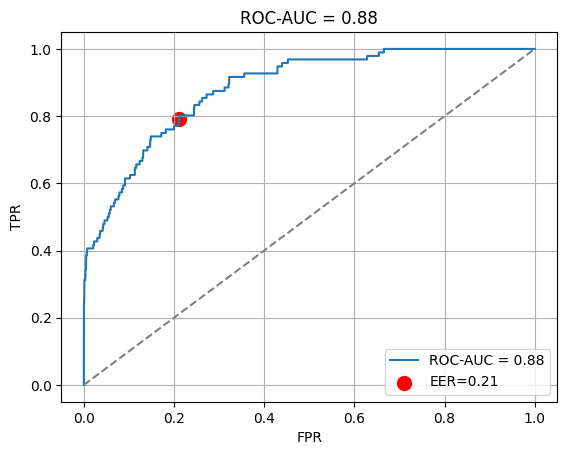

In [69]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=100, label=f'EER={eer:.2f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC-AUC = {auc:.2f}')
plt.legend()
plt.grid(True)
plt.show()

A curva ROC azul bem acima da diagonal confirma o AUC de 0.88, o modelo discrimina bem melhor que o aleatório. A linha diagonal pontilhada representa um classificador aleatório (AUC = 0.5), onde o modelo não conseguiria separar pares positivos de negativos. O ponto vermelho indica o EER de 0.21, ou seja, o threshold onde o modelo erra igualmente aceitando impostores e rejeitando pessoas legítimas.

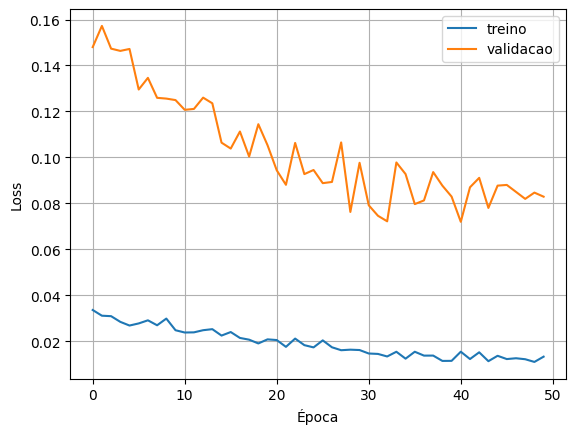

In [70]:
plt.figure()
plt.plot(list_loss_train, label='treino')
plt.plot(list_loss_val, label='validacao')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Observando o gráfico de loss, nota-se um gap de generalização entre as curvas de treino e validação. Embora ambas apresentem tendência de queda, a curva de validação exibe uma oscilação acentuada (ruído) em comparação à estabilidade da curva de treino. Isso sugere que o modelo está começando a se especializar excessivamente nos dados de treinamento, indicando um estágio inicial de overfitting.

## 3.5 Buscando melhorias

Essa seção trata exclusicamente de teste para melhoria do modelo. A ideia a seguir implementar o ReduceLROnPlateau onde é reduzido o learning rate conforme as épocas passam, teoricamente isso ajudaria o modelo a convergir de forma mais suave na validação, eliminando os picos observados. Quando a val loss para de melhorar por N épocas, o scheduler reduz o learning rate por um fator. Por exemplo, se o learning rate estava em 0.001 e o fator é 0.1, ele passa para 0.0001. Isso faz o modelo dar passos menores e possivelmente sair de um platô

Trocar o optimizer para AdamW para usar o weigth_decay e adicionando um dropout no Normalize do modelo também foi implementado. A ideia é que o weigth_decay vai ajustar os pesos adicionando uma penalidade aos pesos do modelo durante o treino, evitando que eles cresçam demais e memorizem o conjunto de treino. Já o dropout desativa aleatoriamente uma porcentagem dos neurônios a cada passagem durante o treino, forçando o modelo a aprender features mais robustas sem depender de neurônios especídificos.

A outra abordagem é adicionar Data Augmentation no dataset de treino, adicionando transformações nas imagens para forçar o modelo a extrair features diferentes. A idea do augmentation é reduzir o overfitting, como o dataset tem poucas imagens por pessoa, o modelo tende a memorizar. Aplicar transformações aleatórias (flip, rotação, variação de brilho) faz o modelo ver versões diferentes a mesma imagem a cada época, dificultando a memorização e forçando a aprender features mais generalizáveis

In [16]:
import torch 
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, train_images, train_identities, transform=None): # recebe os dfs dos caminhos das imagens e o nome da pessoa
        self.train_images = train_images
        self.train_identities = train_identities
        self.transform = transform

    def __len__(self):
        return len(self.train_images)

    def __getitem__(self, idx):
        with Image.open(self.train_images.iloc[idx]) as img: # abrir a imagem
            if self.transform:
                img = self.transform(img)
            image = transforms.ToTensor()(img) # transforma em tensor
            
                
        return image, self.train_identities.iloc[idx] # retorna o tensor da imagem e a pessoa a quem ela corresnponde

In [17]:
train_transform = transforms.Compose([
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(10),
      transforms.ColorJitter(brightness=0.2, contrast=0.2)
  ])


train_dataset = CustomImageDataset(train_images, train_identities, transform=train_transform)
test_dataset = CustomImageDataset(test_images, test_identities)
val_dataset = CustomImageDataset(val_images, val_identities)

In [18]:
from torch.utils.data import Sampler
import random

class CustomSampler(Sampler):
    def __init__(self, dataset, person_per_batch, img_per_person=3):
        self.dataset = dataset
        self.person_per_batch = person_per_batch # recebe o numero de pessoa por batch
        self.img_per_person = img_per_person # recebe o numero de imagens por pessoa
        self.idx_imgs = {} # dicionario para salvar os indices das imagens dessa pessoa
        for idx in range(len(dataset)): # percorre os indices do dataset
            if dataset.train_identities.iloc[idx] not in self.idx_imgs: # se a pessoa nao esta no dataset
                self.idx_imgs[dataset.train_identities.iloc[idx]] =  [] # cria uma lista de indices
            self.idx_imgs[dataset.train_identities.iloc[idx]].append(idx) # adiciona os indices das imagens dessa pessoa

    def __len__(self):
        return len(self.dataset)

    def __iter__(self):
        persons = random.sample(list(self.idx_imgs.keys()), self.person_per_batch) # sorteia pessoas aleatorias do dicionario
        self.lista = []
        for person in persons:
            idxs_list = self.idx_imgs[person] # lista dos indices da pessoa
            idxs = random.sample(idxs_list, self.img_per_person)
            self.lista.extend(idxs)
        return iter(self.lista)

In [19]:
from torch.utils.data import DataLoader
import random

person_per_batch = 32
img_per_person = 3
batch_size = person_per_batch*img_per_person

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=CustomSampler(train_dataset, person_per_batch))
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, sampler=CustomSampler(test_dataset, person_per_batch))
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, sampler=CustomSampler(val_dataset, person_per_batch))

In [20]:
import torch
from torchvision.models import resnet18

backbone = resnet18(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


In [21]:
import torch.nn as nn

backbone.fc = nn.Linear(512, 128)
backbone.fc

Linear(in_features=512, out_features=128, bias=True)

In [22]:
import torch.nn.functional as F

class Normalize(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, img):
        result = self.backbone(img)
        result = self.dropout(result)
        return F.normalize(result)

In [23]:
model = Normalize(backbone)

In [24]:
triplet_loss = nn.TripletMarginLoss(margin=1.0, p=2)

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [26]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

reduce = ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.10)

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Normalize(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [28]:
import numpy as np
import random

list_loss_train = []
list_loss_val = []

best_val_loss = float('inf')
patience_counter = 0 
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_val_loss = 0
    for batch in train_dataloader: # loop sobre os batchs de treino
        images, identities = batch  # extrai os tensores em imagens e identidades
        images = images.to(device) # manda a imagem para o GPU
        embedding = model(images) # extrai as features do rosto de cada imagem do batch com 128 dimensoes cada
        ids = np.array(identities) # transforma os nomes das pessoas em um array
        mask = torch.tensor(ids[:, None] == ids[None, :]) # faz uma matriz de máscaras, onde True indica que é a mesma pessoa e False pessoa diferente
        triplets = [] # lista para armazenar os triplets anchor, positive e negative
        for i in range(len(embedding)): # percorre os index dos embeddings
            positives_idxs = torch.where(mask[i]) # separa os indexs positivos da máscara
            negatives_idxs = torch.where(~mask[i]) # separa os index negativos
            valid_positive = positives_idxs[0][positives_idxs[0] != i].tolist() # converte para uma lista com o filtro diferente do indice
            valid_negative = negatives_idxs[0].tolist()
            if len(valid_positive) == 0 or len(valid_negative) == 0:
                continue      
            positive = random.choice(valid_positive) # escolhe 1 linha postive excluindo o proprio i que será o anchor
            negative = random.choice(valid_negative) # escolhe 1 linha negative
            triplets.append((embedding[i], embedding[positive], embedding[negative])) # salva na lista 
        
        anchors = torch.stack([t[0] for t in triplets]) # desempacota os anchors
        positives = torch.stack([t[1] for t in triplets]) # desempacota os positives
        negatives = torch.stack([t[2] for t in triplets]) # desempacota os negatives
        loss_train = triplet_loss(anchors, positives, negatives) # passa para a funçao de perda
        total_train_loss += loss_train.item()
    
        optimizer.zero_grad() # zera os gradientes antes de calcular novos
        loss_train.backward() # calcula os gradientes
        optimizer.step() # atualiza os pesos

    mean_train_loss = total_train_loss / len(train_dataloader)
    list_loss_train.append(mean_train_loss)

    model.eval()
    for batch in val_dataloader:
        with torch.no_grad():
            images, identities = batch
            images = images.to(device)
            embedding = model(images)
            ids = np.array(identities)
            mask = torch.tensor(ids[:, None] == ids[None, :])
            triplets = [] # lista para armazenar os triplets anchor, positive e negative
            for i in range(len(embedding)): # percorre os index dos embeddings
                positives_idxs = torch.where(mask[i]) # separa os indexs positivos da máscara
                negatives_idxs = torch.where(~mask[i]) # separa os index negativos
                valid_positive = positives_idxs[0][positives_idxs[0] != i].tolist()
                valid_negative = negatives_idxs[0].tolist()
                if len(valid_positive) == 0 or len(valid_negative) == 0:
                    continue      
                positive = random.choice(valid_positive) # escolhe 1 linha postive excluindo o proprio i que será o anchor
                negative = random.choice(valid_negative) # escolhe 1 linha negative
                triplets.append((embedding[i], embedding[positive], embedding[negative])) # salva na lista 
            
            anchors = torch.stack([t[0] for t in triplets]) # desempacota os anchors
            positives = torch.stack([t[1] for t in triplets]) # desempacota os positives
            negatives = torch.stack([t[2] for t in triplets]) # desempacota os negatives
            loss_val = triplet_loss(anchors, positives, negatives) # passa para a funçao de perda
            total_val_loss += loss_val.item()

    
    mean_val_loss = total_val_loss / len(val_dataloader)
    list_loss_val.append(mean_val_loss)
    reduce.step(mean_val_loss)

    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter == 10:
        break

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}')

Epoch 1/50 | Train Loss: 0.0373 | Val Loss: 0.1486
Epoch 2/50 | Train Loss: 0.0365 | Val Loss: 0.1598
Epoch 3/50 | Train Loss: 0.0365 | Val Loss: 0.1513
Epoch 4/50 | Train Loss: 0.0366 | Val Loss: 0.1533
Epoch 5/50 | Train Loss: 0.0360 | Val Loss: 0.1522
Epoch 6/50 | Train Loss: 0.0360 | Val Loss: 0.1348
Epoch 7/50 | Train Loss: 0.0361 | Val Loss: 0.1394
Epoch 8/50 | Train Loss: 0.0360 | Val Loss: 0.1345
Epoch 9/50 | Train Loss: 0.0360 | Val Loss: 0.1346
Epoch 10/50 | Train Loss: 0.0348 | Val Loss: 0.1358
Epoch 11/50 | Train Loss: 0.0340 | Val Loss: 0.1321
Epoch 12/50 | Train Loss: 0.0348 | Val Loss: 0.1384
Epoch 13/50 | Train Loss: 0.0355 | Val Loss: 0.1419
Epoch 14/50 | Train Loss: 0.0353 | Val Loss: 0.1389
Epoch 15/50 | Train Loss: 0.0331 | Val Loss: 0.1194
Epoch 16/50 | Train Loss: 0.0342 | Val Loss: 0.1153
Epoch 17/50 | Train Loss: 0.0322 | Val Loss: 0.1248
Epoch 18/50 | Train Loss: 0.0326 | Val Loss: 0.1175
Epoch 19/50 | Train Loss: 0.0323 | Val Loss: 0.1191
Epoch 20/50 | Train L

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

all_embeddings = []
all_identities = []

with torch.no_grad():
    for batch in test_dataloader: # loop no dataloader de teste
        images, identities = batch
        images = images.to(device)
        embeddings = model(images) # calcula o embedding com o melhor modelo treinado
        all_embeddings.append(embeddings.cpu()) # adiciona na lista de embeddings
        all_identities.extend(identities) # adiciona a pessoa na lista de identidades

all_embeddings = torch.cat(all_embeddings) # junta todos os tensores em 1 só com 519 imagens de teste
dist_matrix = torch.cdist(all_embeddings, all_embeddings) # calcula a distancia entre cada par do tensor de embeddings
ids = np.array(all_identities)
mask = ids[:, None] == ids[None, :] # cria uma matriz de booleanos do tamanho da matriz de distancia, onde True é uma distancia de embedding da mesma pessoa e False de pessoa diferente

dist_positive = dist_matrix[mask & ~np.eye(len(mask), dtype=bool)] # extrai somente as linhas em que é a distancia da mesma pessoa, usando a mask como filtro
dist_negative = dist_matrix[~mask] # extrai somente as linhas em que é a distancia de pessoas diferentes, usando a mask como filtro

pos_array = [1] * len(dist_positive) # label para a distancia positiva
neg_array = [0] * len(dist_negative) # label para a distancia negativa

labels = pos_array + neg_array # concatenado as duas labels em 1 array
distances = np.concatenate((dist_positive.numpy(),dist_negative.numpy())) # concatenando os arrays de distancia

auc = roc_auc_score(labels, -distances) # passamos

fpr, tpr, thresholds = roc_curve(labels, -distances)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = fpr[eer_idx]
print(f'ROC-AUC: {auc:.4f}')
print(f'EER: {eer:.4f}')

ROC-AUC: 0.8361
EER: 0.2464


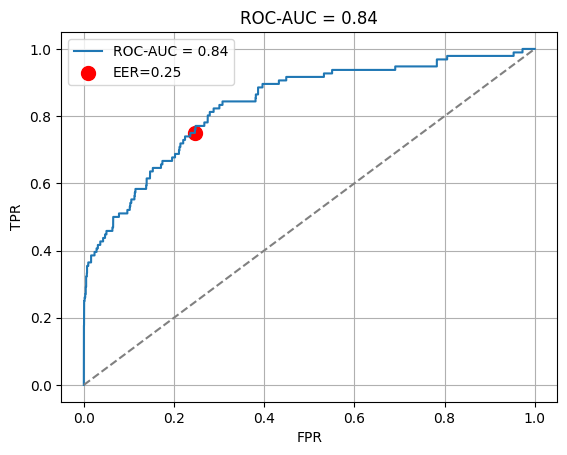

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=100, label=f'EER={eer:.2f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC-AUC = {auc:.2f}')
plt.legend()
plt.grid(True)
plt.show()

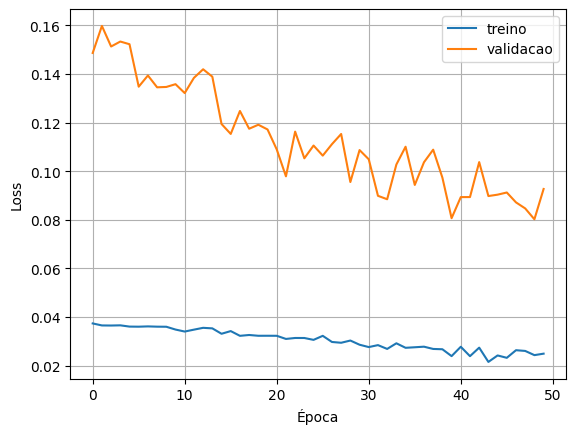

In [31]:
plt.figure()
plt.plot(list_loss_train, label='treino')
plt.plot(list_loss_val, label='validacao')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Observando os resultados, tivemos uma pequena queda em relação com o modelo anterior com o ROC-AUC passando de 88% para 83%. O EER também piorou ppassando de 21% para 24%. O limite provavelmnete é o dataset, 1153 pessoas com apenas 3 imagens cada é muito pouco para Metric Learning. As melhorias que tentamos (dropout, AdamW, scheduler, augmentation) não superaram o modelo base porque o gargalo provalvelmente é a quantidade de dados, não a arquitetura.

# 4 Conclusão

O melhor modelo então foi o primeiro treinado. Com a métrica da ROC-AUC de 88%, o modelo separa bem positivos de negativos e com o Erro de 21% para as duas classes mostrando equilíbrio razoável. Uma possível causa do modelo não ter performado melhor é o tamanho reduzido do dataset após as modificações realizadas, desse modo mesmo com o CustomSampler garantido a formação de pares positivos, fica limitado a formar as combinações usando apenas as 3 imagens por pessoa. Como consequência, a diversidade dos exemplos é restrita, o que impacta negativamente a capacidade de generalização do modelo.

Mesmo após aplicar uma arquitetura mais robusta e treinando o modelo novamente, ele decaiu um pouco em relação ao primeiro, isso reforça a importância de ter um dataset mais diverso para tratar esse problema de reconhecimento facial.

Um teste válido seria limitar para 4 imagens por pessoa e aceitar o trade-off de perder pessoas para formar mais pares e verificar se o modelo aprende melhor com mais pares mesmo tendo menos pessoas